#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0
#### Rocio Nievas

## Introduccion teorica
### Señal sinusoidal
Una señal sinusoidal es una forma de onda periódica que puede representarse mediante la funcion seno o coseno.Su expresion general en un dominio continuo es:

\begin{equation}
x(t)=Vm+A*sen(2*\pi*f*t+φ)
\end{equation}

donde

A[V]:Amplitud de la señal,indica el valor máximo de la señal respecto al eje horizontal 

Vm[V]:Valor medio de la señal,corresponde al promedio de todos los valores en intervalo 

f[Hz]:Frecuencia,indica cuantos ciclos completos ocurren por segundo

t[s]:Variación temporal 

φ[rad]:Fase que representa un corrimiento en el tiempo de la señal 

### Señales en tiempo discreto 
En el procesamiento digital de señales es necesario convertir una señal analógica, definida en tiempo continuo $x(t)$, en una señal discreta que pueda ser procesada por un sistema digital.

Este proceso se denomina muestreo y consiste en tomar muestras de la señal cada un período $Ts$, donde $Ts=1/fs$. Matemáticamente, el muestreo puede interpretarse como la multiplicación de la señal continua por un tren de impulsos, obteniendo una nueva señal dada por
\begin{equation}
xs(t)=x(t)*s(t)
\end{equation}
Cada impulso del tren toma como amplitud el valor instantáneo de la señal original en el correspondiente instante de muestreo.
En el análisis de señales, es necesario convertir señales analógicas, definidas en tiempo continuo $x(t)$, en señales discretas que puedan ser procesadas digitalmente.

### Frecuencia en tiempo discreto
Al realizar el muestreo de una señal continua con una frecuencia de muestreo , su espectro se replica periódicamente cada $fs$. Si la señal original posee un ancho de banda limitado a $fb$ las copias del espectro aparecen centradas en los múltiplos enteros de la frecuencia de muestreo.

Para que la señal original pueda recuperarse correctamente, estas réplicas no deben superponerse entre sí ni con la banda base. En caso contrario, las componentes espectrales se mezclan y se pierde información de manera irreversible, ya que no es posible distinguir qué parte corresponde a la señal original y cuál a una réplica.

Para evitar este fenómeno, conocido como aliasing, debe cumplirse el criterio de Nyquist,
\begin{equation}
fs>2fb
\end{equation}

es decir, la frecuencia de muestreo debe ser mayor que el doble de la máxima frecuencia presente en la señal.

Cuando la frecuencia de la señal se aproxima a la frecuencia de Nyquist $fs/2$, disminuye la cantidad de muestras por período y la representación discreta resulta menos precisa. Si la frecuencia supera este límite, las réplicas espectrales comienzan a solaparse y la señal muestreada aparece con una frecuencia diferente a la original. En consecuencia, distintas señales continuas pueden generar exactamente la misma secuencia de muestras, haciendo imposible distinguirlas únicamente a partir de la información digital obtenida.


## Analisis y desarrollo
En el siguiente trabajo se empieza a utilizar el leguaje python generando una funcion seno con parametros previamente definidos, considerando el muestreo de la señal
Como primer paso se prepara el entorno que se desea trabajar importando las librerias necesaria y definiendo las funciones para lograr



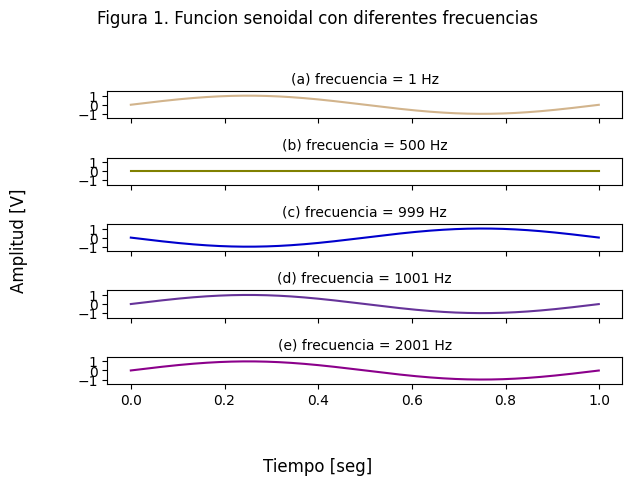

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def eje_temporal (N, fs):
    tt = np.arange(N) / fs
    return tt

def func_senoidal (tt, frec, amp, fase , v_medio ):
    xx = amp * np.sin (2 * np.pi * frec * tt + fase) + v_medio
    return xx

amp = 1
N = 1000
fs = 1000
fase = 0
v_medio = 0
frec = 1

nn = np.arange(N)
tt = eje_temporal(N=N, fs=fs)

s1 = func_senoidal(tt, frec, amp, fase, v_medio)

f2 = 500
f3 = 999
f4 = 1001
f5 = 2001

s2 = func_senoidal(tt, f2, amp, fase, v_medio)
s3 = func_senoidal(tt, f3, amp, fase, v_medio)
s4 = func_senoidal(tt, f4, amp, fase, v_medio)
s5 = func_senoidal(tt, f5, amp, fase, v_medio)

#%%
###################### GRAFICO ######################################
fig, axs = plt.subplots(5, 1, sharex=True)

axs[0].plot(tt, s1, color="tan")
axs[1].plot(tt, s2, color="olive")
axs[2].plot(tt, s3, color="mediumblue")
axs[3].plot(tt, s4, color="rebeccapurple")
axs[4].plot(tt, s5, color="darkmagenta")

# títulos correctos y coherentes con las frecuencias reales
axs[0].set_title("(a) frecuencia = 1 Hz", fontsize=10)
axs[1].set_title("(b) frecuencia = 500 Hz", fontsize=10)
axs[2].set_title("(c) frecuencia = 999 Hz", fontsize=10)
axs[3].set_title("(d) frecuencia = 1001 Hz", fontsize=10)
axs[4].set_title("(e) frecuencia = 2001 Hz", fontsize=10)

# misma escala para que no “explote” visualmente
for ax in axs:
    ax.set_ylim(-1.5, 1.5)
 
# títulos globales
fig.suptitle("Figura 1. Funcion senoidal con diferentes frecuencias")
fig.supxlabel("Tiempo [seg]")
fig.supylabel("Amplitud [V]")

# ajuste de espacios (clave)
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

plt.show()

En la $Figura 1$ se observan cinco señales dobtenidas al variar la frecuencia de la señal mateniendo constante la frecuencia de muestreo en 1000Hz.
La $Figura 1 (a)$ muestra una señal de referencia con amplitud unitarias,valor medio nulo, frecuencia de 1 Hz y fase inicial igual a cero . Dado que se adquirieron (1000) muestras con una frecuencia de muestreo de (1000) Hz, el tiempo total de observación es de un segundo, permitiendo visualizar un ciclo completo de la senoidal.
En la $Figura 1 (b)$ se utilizo una frecuencia de 500 Hz correspondiente a la frecuencia de Nyquist,es decir , la mitad de la frecuencia de muestreo.Al muestrear una señal de 500Hz con una frecuencia de muestreo de 1000Hz, las muestras se toman cada medio periodo  quedando una expresion igual a $x[n]=sen(\pi n)$.Dado que el seno de cualquier multiplo entero de $\pi$ es igual a cero,todas las muestras tienen valor ulo.Esto se evidencia en el grafico donde se observa una linea horizontal en cero.
Las $Figuras 1(c), 1(d) y 1(e)$ corresponden a señales con frecuencias de 999 Hz, 1001 Hz y 2001 Hz, respectivamente. Aunque estas frecuencias son superiores a la frecuencia de muestreo, las señales obtenidas en tiempo discreto resultan prácticamente iguales a una senoidal de 1 Hz. Esto se debe al fenómeno de aliasing, que ocurre porque al muestrear una señal su espectro se replica periódicamente cada fs

En este caso, las frecuencias equivalentes resultan


$f_alias=999-1000= -1Hz$

$f_alias=1001-1000= 1Hz$

$f_alias=2001-2\cdot1000= 1Hz$


Por lo tanto, las señales de 1001 Hz y 2001 Hz generan la misma secuencia de muestras que una senoidal de 1Hz, mientras que la señal de 999 Hz es equivalente a una senoidal de -1Hz, lo que se refleja como un cambio de fase respecto de la señal de referencia.

Esto demuestra que, aunque las señales originales tengan frecuencias muy elevadas, al ser muestreadas pueden representarse como señales de baja frecuencia. Como el sistema solo toma muestras en instantes discretos, las componentes de alta frecuencia y sus frecuencias alias producen exactamente los mismos valores en esos instantes. En consecuencia, no es posible diferenciarlas a partir de las muestras obtenidas, observándose una señal de baja frecuencia como consecuencia del fenómeno de aliasing.

## Conlusion
En este trabajo se pudo observar que el muestreo de una señal continua puede dar lugar a una misma señal discreta cuando sus frecuencias difieren en un múltiplo entero de la frecuencia de muestreo, es decir, $Fk = F0 +kFs$, lo que se conoce como aliasing.Esto genera una indeterminación en la interpretación de la señal, ya que el sistema no puede distinguir entre una frecuencia original elevada y su frecuencia equivalente dentro del rango fundamental.

Asimismo, se verificó la importancia del criterio de Nyquist, el cual establece que la frecuencia de muestreo debe ser, como mínimo, el doble de la máxima frecuencia presente en la señal para evitar el solapamiento de las réplicas espectrales. Cuando esta condición no se cumple, diferentes señales continuas pueden producir la misma secuencia de muestras, haciendo imposible recuperar la señal original únicamente a partir de los datos muestreados.

Finalmente, esta práctica permitió verificar que una elección inadecuada de la frecuencia de muestreo puede hacer que señales con frecuencias diferentes sean indistinguibles en tiempo discreto debido al aliasing. Por este motivo, resulta fundamental seleccionar una frecuencia de muestreo adecuada para representar correctamente la señal y evitar errores en su interpretación.